# Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns



# Funções

In [2]:
def apresentar_estacionariedade(serie, log=True):
    resultado_adf = adfuller(serie)
    resultado_kpss = kpss(serie)
    estacionario = (resultado_adf[1] <= 0.05) and (resultado_kpss[1] > 0.05)
    if (log):
        print("="*40)
        print("Estatística ADF:", resultado_adf[0])
        print("p-valor ADF:", resultado_adf[1])
        print("p-valor KPSS:", resultado_kpss[1])
        print("É estacionário?", "Sim" if estacionario else "Não") # Se for menor igual a 0.05 significa que é estacionário
        print("Valores críticos:")
        for chave, valor in resultado_adf[4].items():
            print(f"    {chave}: {valor}")
    return estacionario
    

In [3]:
def tornar_estacionario(serie, target_column):
    diferenciacao = 0
    while not apresentar_estacionariedade(serie[target_column], False):
        diferenciacao += 1
        serie = serie.diff().dropna()
    
    return serie, diferenciacao

In [4]:
def analisar_series_temporais(df, coluna_data, figsize=(14, 5)):
    """
    Plota todas as colunas numéricas ao longo do tempo
    e gera uma matriz de correlação.

    Parameters
    ----------
    df : pandas.DataFrame
    coluna_data : str
        Nome da coluna ou do índice de data.
    """

    # Cópia para evitar alterar o dataframe original
    df_plot = df.copy()

    if coluna_data in df_plot.columns:
        df_plot[coluna_data] = pd.to_datetime(df_plot[coluna_data])
        df_plot = df_plot.sort_values(coluna_data)
        eixo_temporal = df_plot[coluna_data]
    elif df_plot.index.name == coluna_data:
        df_plot.index = pd.to_datetime(df_plot.index)
        df_plot = df_plot.sort_index()
        eixo_temporal = df_plot.index
    else:
        raise ValueError(
            f"'{coluna_data}' não foi encontrada como coluna nem como nome do índice."
        )

    # Seleciona colunas numéricas
    colunas_numericas = df_plot.select_dtypes(include=np.number).columns

    # Plota cada série temporal
    for coluna in colunas_numericas:
        plt.figure(figsize=figsize)

        plt.plot(
            eixo_temporal,
            df_plot[coluna]
        )

        plt.title(f"{coluna} ao longo do tempo")
        plt.xlabel(coluna_data)
        plt.ylabel(coluna)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Correlação
    correlacao = df_plot[colunas_numericas].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlacao,
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title("Matriz de Correlação")
    plt.tight_layout()
    plt.show()

    return correlacao

In [5]:
def calcular_vif(df, colunas=None):
    """
    Calcula o Variance Inflation Factor (VIF) para as colunas informadas.

    Parameters
    ----------
    df : pandas.DataFrame
    colunas : list[str], optional
        Colunas a serem consideradas. Se None, utiliza todas as numéricas.

    Returns
    -------
    pandas.DataFrame
        DataFrame contendo Feature e VIF.
    """

    if colunas is None:
        colunas = df.select_dtypes(include=np.number).columns.tolist()

    X = df[colunas].copy()

    # Remove linhas com NaN
    X = X.dropna()

    vif_df = pd.DataFrame({
        "Feature": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })

    return vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)

# Pegando dados

In [6]:
df_raw = pd.read_csv("data/Pilgrim_s_Pride_Corporation.csv")

TARGET = "Close"
DATE_COLUMN = "Date"

# Converte todas as datas para o mesmo padrão
df_raw[DATE_COLUMN] = pd.to_datetime(
    df_raw[DATE_COLUMN],
    errors="coerce",
    utc=True
).dt.tz_localize(None)

df_raw = df_raw.dropna(subset=[DATE_COLUMN])

# Apenas datas posteriores a 2013
df_raw = df_raw.loc[
    df_raw[DATE_COLUMN] >= pd.Timestamp("2014-01-01")
].copy()

df_raw = (
    df_raw
    .set_index(DATE_COLUMN)
    .sort_index()
    .drop(columns=["Open", "High", "Low"], errors="ignore")
)

df_raw.head(2)

,Close,Volume,Dividends,Stock Splits
Date,,,,
2014-01-02 05:00:00,10.213264,450600,0.0,0.0
2014-01-03 05:00:00,10.245281,551200,0.0,0.0


## Estacionariedade

In [7]:
is_estacionario = apresentar_estacionariedade(df_raw[TARGET])

Estatística ADF: -1.9900831174531195
p-valor ADF: 0.2909381631575668
p-valor KPSS: 0.01
É estacionário? Não
Valores críticos:
    1%: -3.4323990179290305
    5%: -2.862445331726794
    10%: -2.567251928447555


C:\Users\gabrielferreira-ieg\AppData\Local\Temp\ipykernel_5268\4227567447.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado_kpss = kpss(serie)


In [8]:
if (not is_estacionario):
    df_estacionario, diferenciacao = tornar_estacionario(df_raw, TARGET)
else:
    diferenciacao = 0

print("Ordem:",diferenciacao)

Ordem: 1


C:\Users\gabrielferreira-ieg\AppData\Local\Temp\ipykernel_5268\4227567447.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado_kpss = kpss(serie)
C:\Users\gabrielferreira-ieg\AppData\Local\Temp\ipykernel_5268\4227567447.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado_kpss = kpss(serie)


## Escalonando a base

In [9]:
scaler = StandardScaler().set_output(transform="pandas")

df_escalonado = df_estacionario.copy()

# Correlação

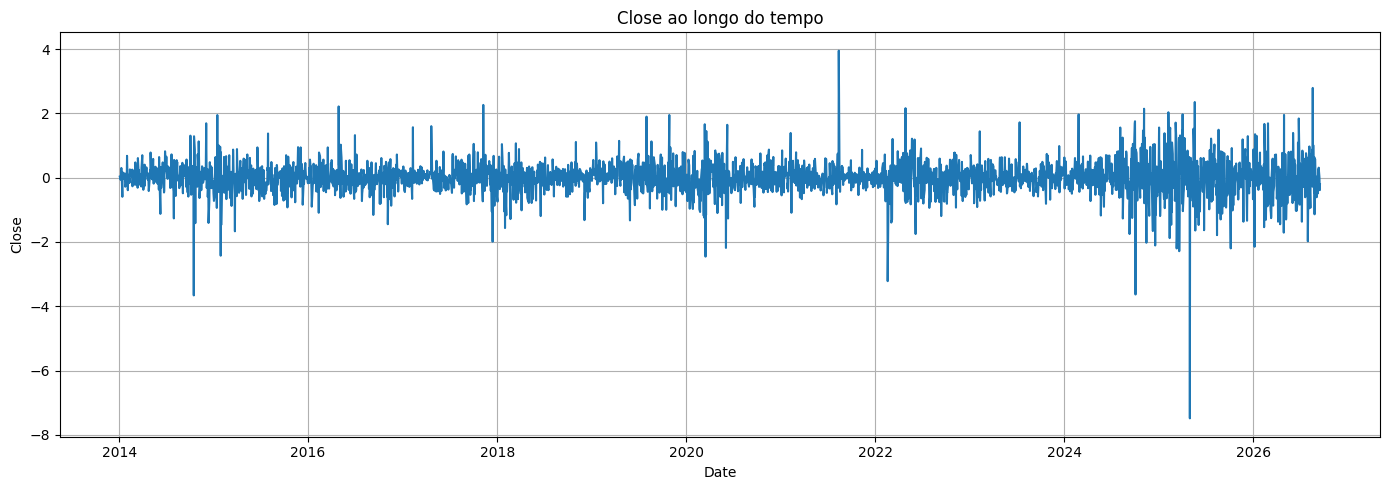

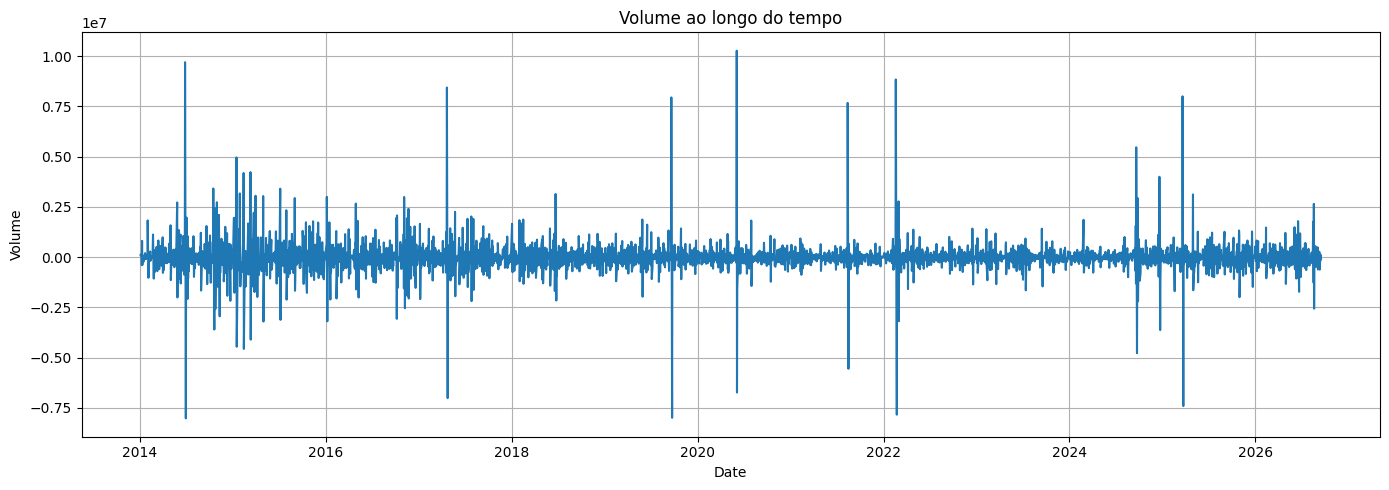

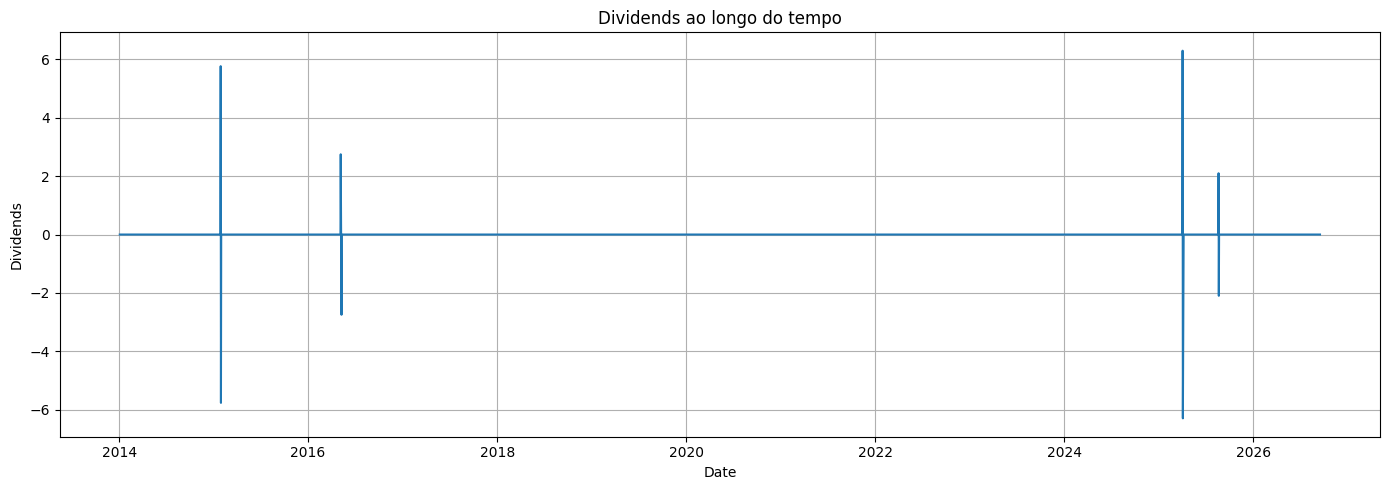

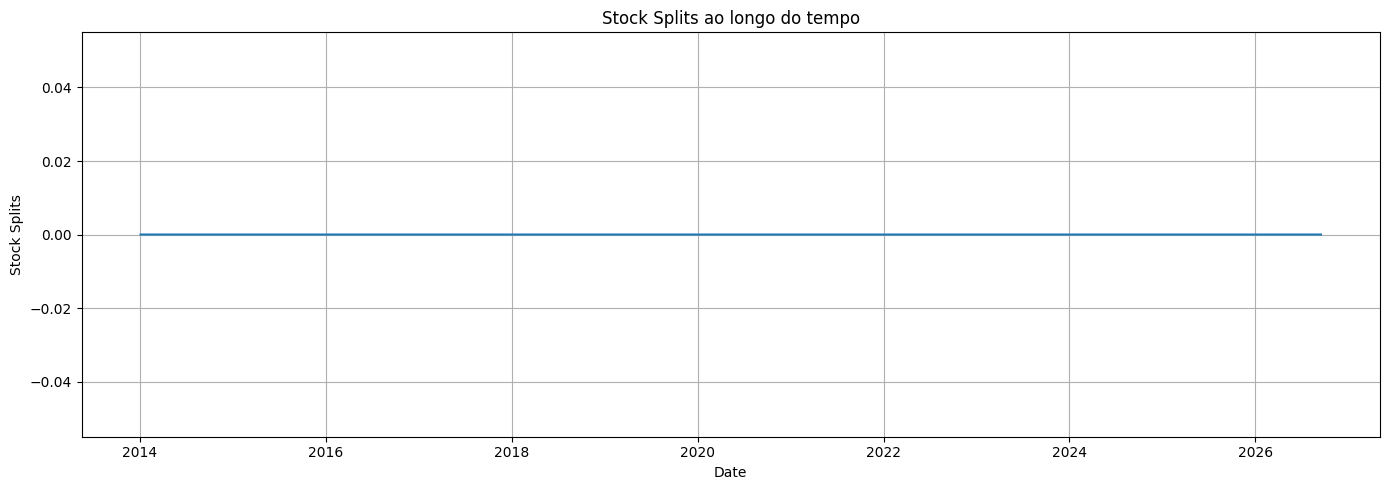

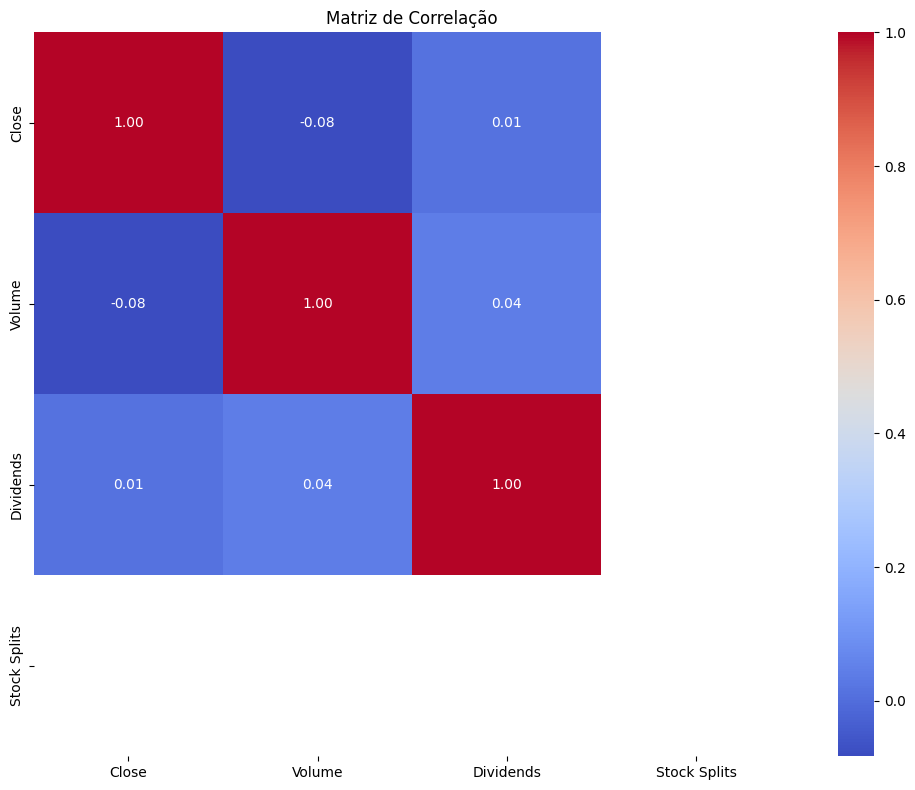

,Close,Volume,Dividends,Stock Splits
Close,1.000000,-0.082871,0.011587,NaN
Volume,-0.082871,1.000000,0.039868,NaN
Dividends,0.011587,0.039868,1.000000,NaN
Stock Splits,NaN,NaN,NaN,NaN


In [10]:
analisar_series_temporais(df_escalonado, DATE_COLUMN)

> Não iremos utilizar nenhuma exogena, pois todas são extremamente proximas do 0

In [11]:
df_escalonado = df_escalonado.drop(columns=["Volume","Dividends", "Stock Splits"])

# Separar treino e teste e escalonando

In [12]:
# pensando em 3 dias para prever
h = int(len(df_escalonado) * 0.25)
train = df_escalonado.iloc[:-h]

test  = df_escalonado.iloc[-h:]


In [21]:
df_escalonado.to_csv("data/base_escalonada.csv")

# PACF e ACF

<Figure size 1000x400 with 0 Axes>

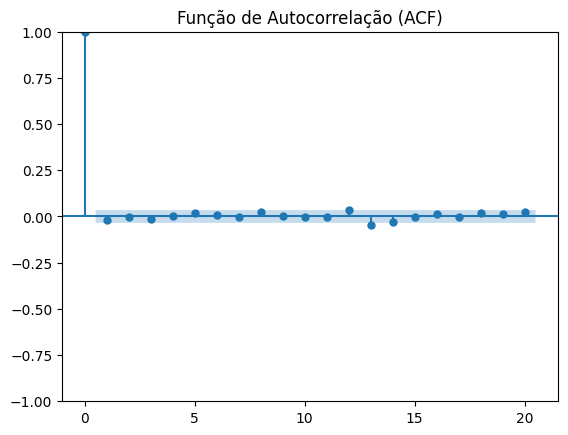

<Figure size 1000x400 with 0 Axes>

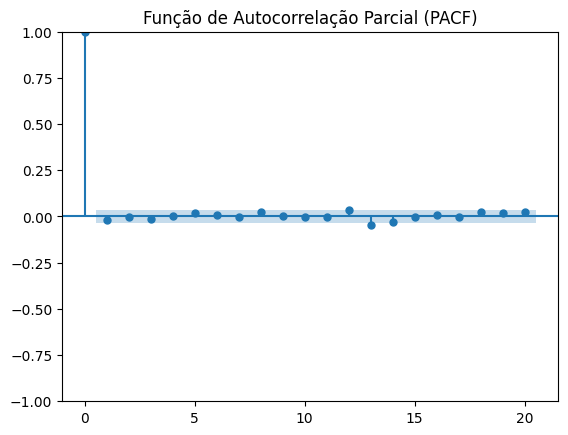

In [13]:
MAX_LAG = 20
plt.figure(figsize=[10,4])
plot_acf(df_escalonado[TARGET], lags=MAX_LAG, title="Função de Autocorrelação (ACF)")
plt.show()

plt.figure(figsize=[10,4])
plot_pacf(df_escalonado[TARGET], lags=MAX_LAG, title="Função de Autocorrelação Parcial (PACF)")
plt.show()

# STL (Força de sazonalidade)

37 - 0.140

92 - 0.172

In [14]:
# range_m = range(2, 101)
# forcas_sazonalidades = []
# qtd_ms = max(range_m)
# for m in range_m:
#     stl = STL(df_escalonado[TARGET], period=m, robust=True).fit()
#     forca_sazonalidade = 1 - (np.var(stl.resid) / np.var(stl.seasonal + stl.resid))
#     forcas_sazonalidades.append({"m":m, "forca":forca_sazonalidade}) 
#     print(f"[{m}/{qtd_ms}] M calculado")

# forcas_sazonalidades = sorted(forcas_sazonalidades, key=lambda x: x["forca"],reverse=True)
# forcas_sazonalidades

> Melhor M escolhido: 27

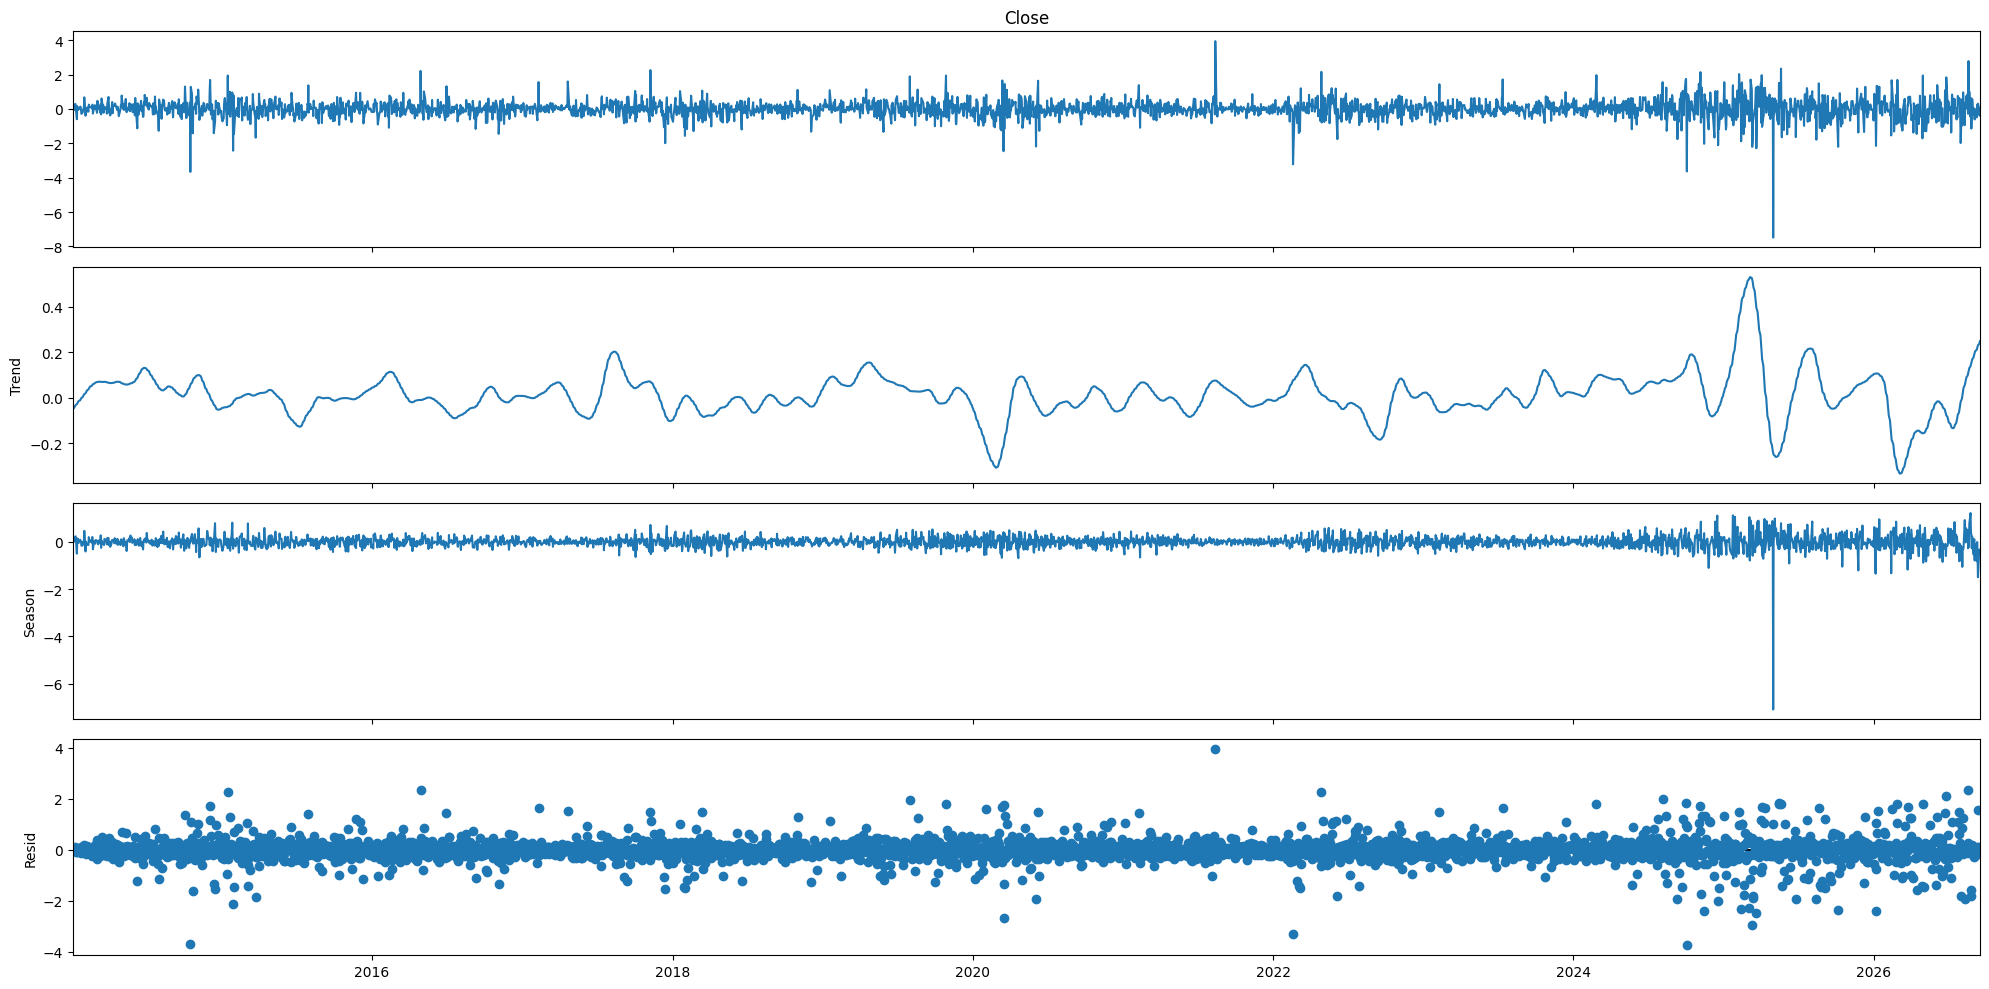

In [15]:
m = 27
stl = STL(df_escalonado[TARGET], period=m, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(20,10)
plt.tight_layout()
plt.show()

In [16]:
forca_sazonalidade = 1 - (np.var(stl.resid) / np.var(stl.seasonal + stl.resid))

print(f"Força de sazonalidade (0-1): {forca_sazonalidade:.4f}")

Força de sazonalidade (0-1): 0.2091


In [17]:
# espaco de busca
m = 27
p_range = [0,1,2]
d_range = [0,1]
q_range = [0,1,2]
P_range = [0,1,2]
D_range = [0,1]
Q_range = [0,1,2]

def tentar_sarimax(order, seasonal_order, y):
    try:
        model = SARIMAX(
            y,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        res = model.fit(disp=False, maxiter=100)
        return res

    except Exception:
        return None


In [18]:
import json
import os

In [24]:
models = []
arquivo = "modelos_sarimax.json"

for p in p_range:
    for d in d_range:
        for q in q_range:
            for P in P_range:
                for D in D_range:
                    for Q in Q_range:
                        print(f"\nModelo: {p},{d},{q} | {P},{D},{Q}")

                        # Se o arquivo não existir, cria uma lista vazia
                        if os.path.exists(arquivo):
                            with open(arquivo, "r", encoding="utf-8") as f:
                                dados = json.load(f)
                        else:
                            dados = []

                        ja_existe = any(
                            item.get("parameters") == [[p,d,q],[P,D,Q,m]]
                            for item in dados
                        )

                        if ja_existe:
                            continue

                        modelo = tentar_sarimax((p,d,q),(P,D,Q,m), train[TARGET])
                        if modelo:
                            print("Bic:", modelo.bic)
                            json_modelo = {"parameters":((p,d,q),(P,D,Q,m)), "bic":modelo.bic}
                        
                            # Adiciona o novo dicionário
                            dados.append(json_modelo)

                            # Salva novamente
                            with open(arquivo, "w", encoding="utf-8") as f:
                                json.dump(dados, f, ensure_ascii=False, indent=4)


Modelo: 0,0,0 | 0,0,0

Modelo: 0,0,0 | 0,0,1

Modelo: 0,0,0 | 0,0,2

Modelo: 0,0,0 | 0,1,0

Modelo: 0,0,0 | 0,1,1

Modelo: 0,0,0 | 0,1,2

Modelo: 0,0,0 | 1,0,0

Modelo: 0,0,0 | 1,0,1

Modelo: 0,0,0 | 1,0,2

Modelo: 0,0,0 | 1,1,0

Modelo: 0,0,0 | 1,1,1

Modelo: 0,0,0 | 1,1,2

Modelo: 0,0,0 | 2,0,0

Modelo: 0,0,0 | 2,0,1

Modelo: 0,0,0 | 2,0,2

Modelo: 0,0,0 | 2,1,0

Modelo: 0,0,0 | 2,1,1

Modelo: 0,0,0 | 2,1,2

Modelo: 0,0,1 | 0,0,0

Modelo: 0,0,1 | 0,0,1

Modelo: 0,0,1 | 0,0,2

Modelo: 0,0,1 | 0,1,0

Modelo: 0,0,1 | 0,1,1

Modelo: 0,0,1 | 0,1,2

Modelo: 0,0,1 | 1,0,0

Modelo: 0,0,1 | 1,0,1

Modelo: 0,0,1 | 1,0,2

Modelo: 0,0,1 | 1,1,0

Modelo: 0,0,1 | 1,1,1

Modelo: 0,0,1 | 1,1,2

Modelo: 0,0,1 | 2,0,0

Modelo: 0,0,1 | 2,0,1

Modelo: 0,0,1 | 2,0,2

Modelo: 0,0,1 | 2,1,0

Modelo: 0,0,1 | 2,1,1

Modelo: 0,0,1 | 2,1,2

Modelo: 0,0,2 | 0,0,0

Modelo: 0,0,2 | 0,0,1

Modelo: 0,0,2 | 0,0,2

Modelo: 0,0,2 | 0,1,0

Modelo: 0,0,2 | 0,1,1

Modelo: 0,0,2 | 0,1,2

Modelo: 0,0,2 | 1,0,0

Modelo: 0,

C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Bic: 2890.0970469763124

Modelo: 2,1,2 | 0,0,0


C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Bic: 2829.5792793121436

Modelo: 2,1,2 | 0,0,1


...

Bic: 3416.9553802432715

Modelo: 2,1,2 | 2,1,1


C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Bic: 2893.98143419077

Modelo: 2,1,2 | 2,1,2


C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Bic: 2894.6617120143364


In [25]:
if os.path.exists(arquivo):
    with open(arquivo, "r", encoding="utf-8") as f:
        models = json.load(f)

melhor_resultado = sorted(models, key=lambda x: x["bic"])[0]
melhores_parametros = melhor_resultado["parameters"]

print("Melhores parametros:", melhores_parametros)
print("Melhor BIC", melhor_resultado["bic"])

melhor_modelo = tentar_sarimax(melhores_parametros[0], melhores_parametros[1], train[TARGET])

fc_melhor = melhor_modelo.forecast(steps=h)
mae_melhor = mean_absolute_error(test[TARGET], fc_melhor)

print("MAE do melhor modelo:", mae_melhor)

Melhores parametros: [[0, 0, 0], [0, 0, 2, 27]]
Melhor BIC 2791.5861263173383


C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\gabrielferreira-ieg\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


MAE do melhor modelo: 0.49388698581386725


In [ ]:
melhores_params = [[0, 0, 0], [0, 0, 2, 27]]
MAE_MELHOR = 0.49388698581386725